In [2]:
# Source - https://stackoverflow.com/a
# Posted by matthiash, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-09, License - CC BY-SA 3.0

from IPython.display import HTML
HTML('''<script>
code_show_err=false; 
function code_toggle_err() {
 if (code_show_err){
 $('div.output_stderr').hide();
 } else {
 $('div.output_stderr').show();
 }
 code_show_err = !code_show_err
} 
$( document ).ready(code_toggle_err);
</script>
To toggle on/off output_stderr, click <a href="javascript:code_toggle_err()">here</a>.''')

In [1]:
from pathlib import Path
from os import environ


# IN_COLAB = False
# if "DRIVE_HOME" in environ:
  # ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
# else:
ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/binom2d")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic-bias")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/data
Using outputdir=/mnt/zfs/jupyter-p03/home/a383ahme/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/binom2d/wbic-bias


In [2]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,p0,p1,w0,w1
0,regular,0.15,0.35,0.75,0.25
1,e-singular,0.25,0.35,0.75,0.25
2,singular1,0.15,0.35,1.00,0.00
3,singular2,0.35,0.35,0.75,0.25


In [3]:
from sklearn_extensions.mixbinom import BinomialMixture


def find_truth_by_dsid(dsid: str):
  dgp = dgps.query(f"dsid=='{dsid}'")
  truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
  return truth

def rlct_by_dsid(dsid: str):
  truth = find_truth_by_dsid(dsid)
  n_components = np.ceil(len(truth)/2)
  rlct = None
  match dsid:
    case "regular" | "e-singular":
      rlct = (n_components*2-1)/2
    case "singular1" | "singular2":
      rlct = 1
    case _:
      raise Exception(f"Uknown dsid={dsid}")

  return rlct

def approx_free_energy_by_dsid(dsid, n_trials, X):
  n=len(X)
  
  average_log_likelihood = None
  model = BinomialMixture(n_components=2, n_trials=n_trials, enforce_ordering=False)
  input_data = np.column_stack([X, np.full_like(X, n_trials)])
  model.fit(input_data)
  mle, _ = model.point_estimate()
  log_p = mixbinom.logpmf(weights=[mle[2], 1-mle[2]], probs=[mle[0], mle[1]], n=n_trials, x=X) # sample likelihood under the mle
  average_log_likelihood = log_p.mean()

  afe = -n_obs*average_log_likelihood+rlct_by_dsid(dsid)*np.log(n_obs)
  return afe


def expected_free_energy_by_dsid(dsid, n_trials, n):
  X = np.arange(0, n_trials, 1)
  truth = find_truth_by_dsid(dsid)
  weights_0=truth[2:3]
  probs_0=truth[0:1]

  log_q = mixbinom.logpmf(n=n_trials, weights=weights_0, probs=probs_0, x=X)
  log_p = mixbinom.logpmf(n=n_trials, weights=weights_0, probs=probs_0, x=X)
  expected_log_likelihood = np.exp(log_q)*log_p
  second_order_term = rlct_by_dsid(dsid)*np.log(n)

  efe = -n * expected_log_likelihood.sum() + second_order_term
  return efe

In [4]:
# compute AFE and WBIC for many samples, 
# AFE requires sampling with beta=1 while WBIC requires sampling with beta=1/sqrt(n)
# for different n

In [5]:
import pandas as pd
import json
from pathlib import Path

results_file = Path(f"{outputdir}/fe_estimators_results.csv")

# Load existing results if file exists
if results_file.exists():
  fe_estimators_df = pd.read_csv(results_file)
  # Create a set of completed (run, regime, dsid) tuples for fast lookup
  completed = set(
      zip(fe_estimators_df["trial"], fe_estimators_df["regime"], fe_estimators_df["dsid"])
  )
  fe_estimators_data = fe_estimators_df.to_dict("records")
else:
  completed = set()
  fe_estimators_data = []

def save_results():
  """Save current results to disk."""
  pd.DataFrame(fe_estimators_data).to_csv(results_file, index=False)

In [ ]:
from pymc_extensions.tempered_mixbinom import TemperedBinomialMixture
from pymc_extensions import pmx
from scipy_extensions import mixbinom
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az


n_components = 2
n_trials=100
regimes = [50, 250, 5000]

# mcmc settings
n_tune=4000
n_draws=1000
n_chains=4

# read all the data so we can nicely loop 
for run in tqdm(range(1000), desc=f"runs "):
  if run > 50:
    break

  for regime in tqdm(regimes, desc="regimes"):
    for dsid in dgps["dsid"].unique():
      # Skip if already completed
      if (run, regime, dsid) in completed:
          continue

      # try:
      dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")

      X = dataset.iloc[:, run].to_numpy()
      n_obs = len(X)
      efe = expected_free_energy_by_dsid(dsid=dsid, n_trials=n_trials, n=n_obs)
      afe = approx_free_energy_by_dsid(dsid=dsid, n_trials=n_trials, X=X)

      with TemperedBinomialMixture(X=X, n_trials=100, beta=1/np.log(n_obs)) as model:
        idata = model.sample(draws=n_draws, 
                             tune=n_tune, 
                             chains=n_chains, 
                             progressbar=True)  # or "blackjax"

        # Divergences are stored in sample_stats as a boolean array (chain, draw)
        diverging = idata.sample_stats.diverging.values
        
        # Divergences per chain
        divs_per_chain = diverging.sum(axis=1)  # array with one value per chain
        
        # Summary statistics
        mean_divergences = divs_per_chain.mean()
        total_divergences = diverging.sum()
        max_divergences = divs_per_chain.max()
        
        weights = pmx.column_stack_vars(idata, ["weights"])
        probs = pmx.column_stack_vars(idata, ["p0", "p1"])
        log_likelihood = mixbinom.log_likelihood(weights, probs, n=n_trials, x=X)
        wbic = -log_likelihood.mean()
        print(f"wbic={wbic}, afe={afe}, efe={efe}")
        result = {
          "dsid": dsid,
          "regime": regime,
          "n": regime,
          "trial": run,
          "wbic": wbic,
          "afe": afe,
          "efe": efe,
          "chains": n_chains,
          "draws": n_draws,
          "tune": n_tune,
          "mean_divergences": mean_divergences,
          "total_divergences": total_divergences,
          "max_divergences": max_divergences,
          "divergences_per_chain": divs_per_chain.tolist(),
          "chain_tree_depth": idata.sample_stats.tree_depth.values.max()
        }

        fe_estimators_data.append(result)
        completed.add((run, regime, dsid))
        
  # Save after each successful run
  save_results()

runs :   0%|          | 0/1000 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

regimes:   0%|          | 0/3 [00:00<?, ?it/s]

...

wbic=13435.6912546058, afe=13437.153576469298, efe=13450.293282320405


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

In [10]:
fe_estimates_df = pd.DataFrame(fe_estimators_data)
fe_estimates_df.style.format({'wbic': '{:.3f}', 'efe': '{:.3f}'})
fe_estimates_df.head()

,dsid,regime,n,trial,wbic,afe,efe,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth
0,regular,50,50,0,166.507481,166.578931,117.469433,4,1000,4000,0.0,0,0,"[0, 0, 0, 0]",7
1,e-singular,50,50,0,160.889827,160.984006,124.783030,4,1000,4000,0.0,0,0,"[0, 0, 0, 0]",9
2,singular1,50,50,0,143.658315,143.038994,138.329784,4,1000,4000,0.0,0,0,"[0, 0, 0, 0]",9
3,singular2,50,50,0,153.285043,153.377789,126.482927,4,1000,4000,0.0,0,0,"[0, 0, 0, 0]",10
4,regular,250,250,0,842.225449,842.385138,566.289183,4,1000,4000,0.0,0,0,"[0, 0, 0, 0]",7


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Compute the differences
fe_estimates_df['wbic_minus_afe'] = fe_estimates_df['wbic'] - fe_estimates_df['afe']
fe_estimates_df['wbic_minus_efe'] = fe_estimates_df['wbic'] - fe_estimates_df['efe']

# Summary statistics
summary = fe_estimates_df.groupby(['dsid', 'n']).agg(
    wbic_afe_mean=('wbic_minus_afe', 'mean'),
    wbic_afe_std=('wbic_minus_afe', 'std'),
    wbic_efe_mean=('wbic_minus_efe', 'mean'),
    wbic_efe_std=('wbic_minus_efe', 'std'),
).reset_index()

# Get RLCT for each dsid
dsids = fe_estimates_df['dsid'].unique()
n_range = np.linspace(fe_estimates_df['n'].min(), fe_estimates_df['n'].max(), 100)

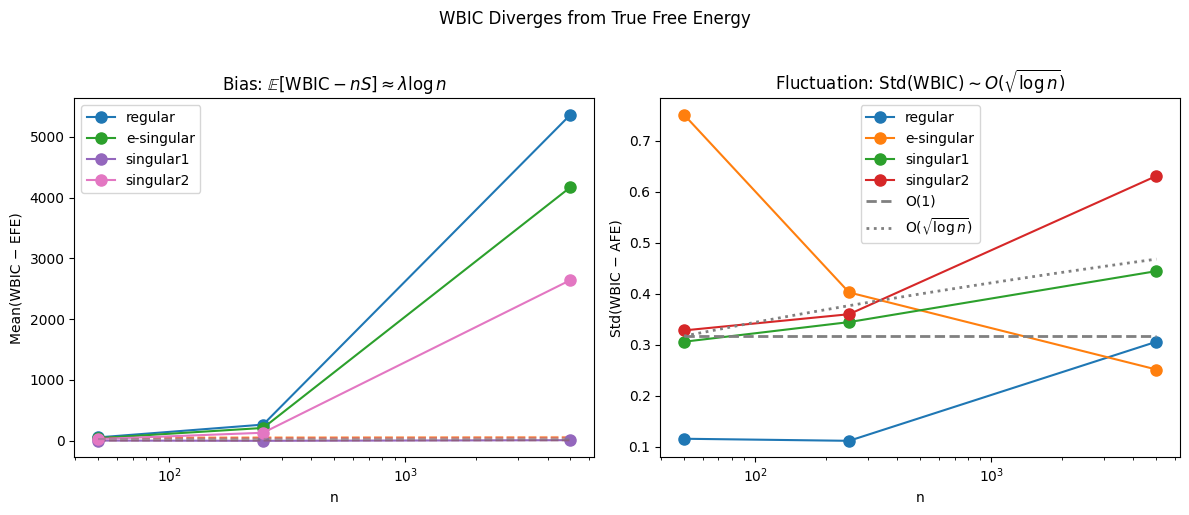

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Bias (Mean of WBIC - EFE) ~ λ log(n)
ax = axes[0]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    ax.plot(data['n'], data['wbic_efe_mean'], 'o-', label=dsid, markersize=8)
    
    # Theoretical reference: λ log(n) anchored at first point
    lam = rlct_by_dsid(dsid)
    n0 = data['n'].iloc[0]
    offset = data['wbic_efe_mean'].iloc[0] - lam * np.log(n0)
    ax.plot(n_range, lam * np.log(n_range) + offset, '--', alpha=0.5)

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel('Mean(WBIC − EFE)')
ax.set_title(r'Bias: $\mathbb{E}[\mathrm{WBIC} - nS] \approx \lambda \log n$')
ax.legend()

# Right: Fluctuation (Std of WBIC - AFE) ~ √log(n)
ax = axes[1]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    ax.plot(data['n'], data['wbic_afe_std'], 'o-', label=dsid, markersize=8)

# Reference lines
n0 = summary['n'].min()
std0 = summary[summary['n'] == n0]['wbic_afe_std'].median()

ax.plot(n_range, np.full_like(n_range, std0), '--', color='gray', linewidth=2, label='O(1)')
c = std0 / np.sqrt(np.log(n0))
ax.plot(n_range, c * np.sqrt(np.log(n_range)), ':', color='gray', linewidth=2, label=r'O($\sqrt{\log n}$)')

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel('Std(WBIC − AFE)')
ax.set_title(r'Fluctuation: $\mathrm{Std}(\mathrm{WBIC}) \sim O(\sqrt{\log n})$')
ax.legend()

plt.suptitle('WBIC Diverges from True Free Energy', y=1.02)
plt.tight_layout()
plt.show()

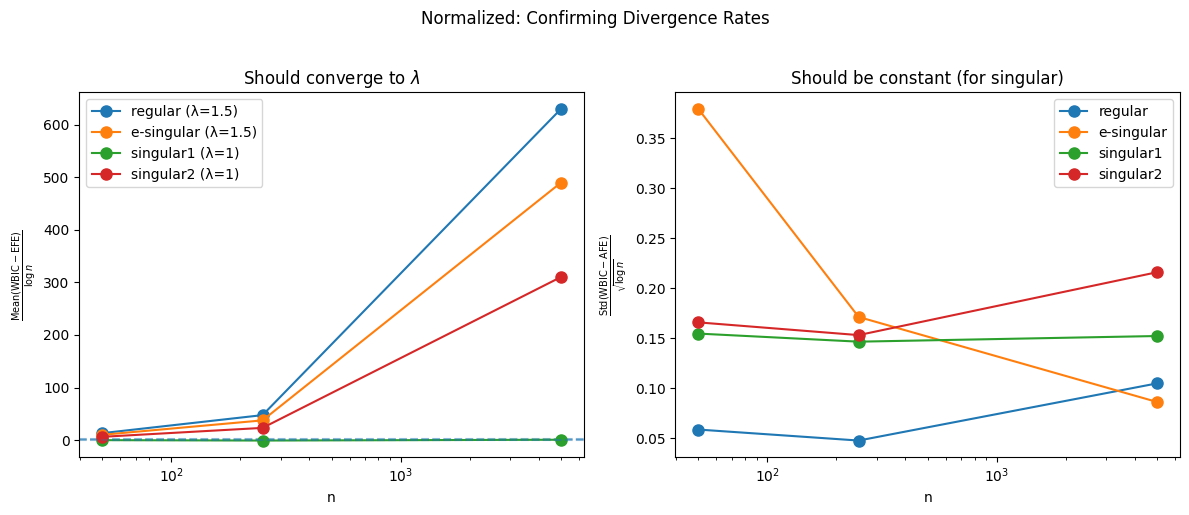

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Bias / log(n) → λ
ax = axes[0]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    normalized = data['wbic_efe_mean'] / np.log(data['n'])
    lam = rlct_by_dsid(dsid)
    ax.plot(data['n'], normalized, 'o-', label=f'{dsid} (λ={lam})', markersize=8)
    ax.axhline(lam, linestyle='--', alpha=0.3)

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel(r'$\frac{\mathrm{Mean(WBIC - EFE)}}{\log n}$')
ax.set_title(r'Should converge to $\lambda$')
ax.legend()

# Right: Std / √log(n) → constant
ax = axes[1]
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    normalized = data['wbic_afe_std'] / np.sqrt(np.log(data['n']))
    ax.plot(data['n'], normalized, 'o-', label=dsid, markersize=8)

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel(r'$\frac{\mathrm{Std(WBIC - AFE)}}{\sqrt{\log n}}$')
ax.set_title('Should be constant (for singular)')
ax.legend()

plt.suptitle('Normalized: Confirming Divergence Rates', y=1.02)
plt.tight_layout()
plt.show()

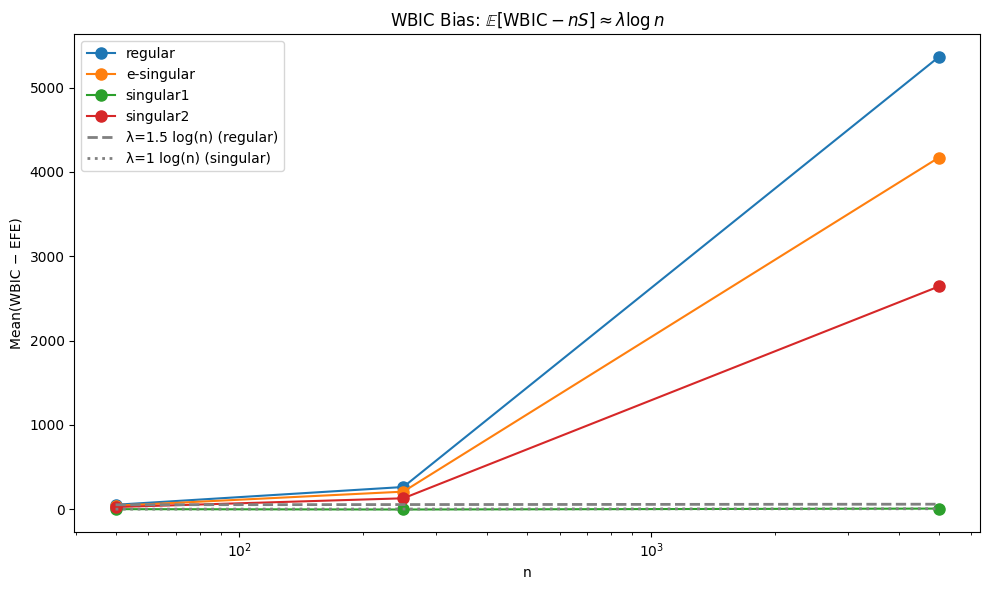

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Compute the differences
fe_estimates_df['wbic_minus_efe'] = fe_estimates_df['wbic'] - fe_estimates_df['efe']

# Summary statistics
summary = fe_estimates_df.groupby(['dsid', 'n']).agg(
    wbic_efe_mean=('wbic_minus_efe', 'mean'),
).reset_index()

dsids = fe_estimates_df['dsid'].unique()
n_range = np.linspace(fe_estimates_df['n'].min(), fe_estimates_df['n'].max(), 100)

# Get RLCT values
rlct_regular = rlct_by_dsid('regular')
rlct_singular = rlct_by_dsid('singular1')  # or whichever singular dsid you want as reference

fig, ax = plt.subplots(figsize=(10, 6))

# Plot data for each dsid
for dsid in dsids:
    data = summary[summary['dsid'] == dsid]
    ax.plot(data['n'], data['wbic_efe_mean'], 'o-', label=dsid, markersize=8)

# Reference line for regular: λ_regular * log(n)
data_reg = summary[summary['dsid'] == 'regular']
n0 = data_reg['n'].iloc[0]
offset_reg = data_reg['wbic_efe_mean'].iloc[0] - rlct_regular * np.log(n0)
ax.plot(n_range, rlct_regular * np.log(n_range) + offset_reg, '--', 
        color='gray', linewidth=2, label=f'λ={rlct_regular} log(n) (regular)')

# Reference line for singular: λ_singular * log(n)
data_sing = summary[summary['dsid'] == 'singular1']
n0 = data_sing['n'].iloc[0]
offset_sing = data_sing['wbic_efe_mean'].iloc[0] - rlct_singular * np.log(n0)
ax.plot(n_range, rlct_singular * np.log(n_range) + offset_sing, ':', 
        color='gray', linewidth=2, label=f'λ={rlct_singular} log(n) (singular)')

ax.set_xscale('log')
ax.set_xlabel('n')
ax.set_ylabel('Mean(WBIC − EFE)')
ax.set_title(r'WBIC Bias: $\mathbb{E}[\mathrm{WBIC} - nS] \approx \lambda \log n$')
ax.legend()

plt.tight_layout()
plt.show()

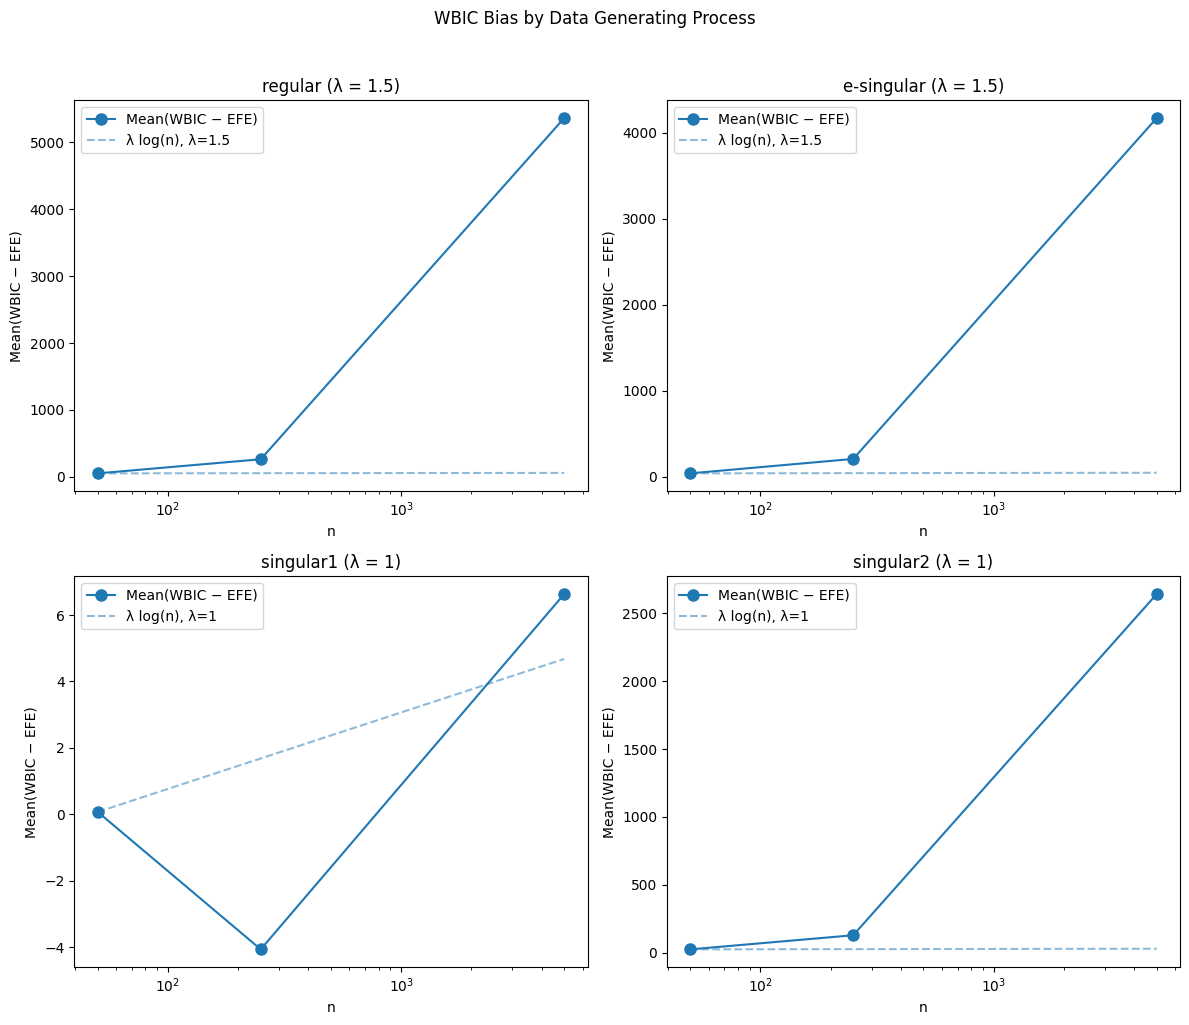

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, dsid in zip(axes, dsids):
    data = summary[summary['dsid'] == dsid]
    lam = rlct_by_dsid(dsid)
    
    # Plot bias
    ax.plot(data['n'], data['wbic_efe_mean'], 'o-', color='C0', label='Mean(WBIC − EFE)', markersize=8)
    
    # Theoretical λ log(n)
    n0 = data['n'].iloc[0]
    offset = data['wbic_efe_mean'].iloc[0] - lam * np.log(n0)
    ax.plot(n_range, lam * np.log(n_range) + offset, '--', color='C0', alpha=0.5, label=f'λ log(n), λ={lam}')
    
    ax.set_xscale('log')
    ax.set_xlabel('n')
    ax.set_ylabel('Mean(WBIC − EFE)')
    ax.set_title(f'{dsid} (λ = {lam})')
    ax.legend()

plt.suptitle('WBIC Bias by Data Generating Process', y=1.02)
plt.tight_layout()
plt.show()